# Projeto Final - Analise de eventos LHE

## Parte 1: Leitura do LHE para `pandas.DataFrame`

Este notebook e uma opcao de trabalho para estudantes. Ele nao contem codigo
pronto.

A ideia e usar cada celula de instrucao para pedir a um agente que gere o codigo
correspondente ao metodo **dataframe**. Depois, copie o codigo produzido pelo
agente para a celula vazia logo abaixo e execute no seu ambiente.

Arquivos da amostra:

- sinal: `../data/sinal.lhe.gz`;
- fundo: `../data/fundo.lhe.gz`.

Mantenha as respostas, tabelas, figuras e interpretacoes no proprio notebook.


## 0. Preparação no Google Colab

Antes de iniciar a análise, siga este fluxo no ambiente do Google Colab:

1. No GitHub, baixe o arquivo ZIP deste repositório (**Code → Download ZIP**) e baixe também o notebook desta tarefa que você vai executar.
2. Abra o notebook no Colab e use o painel **Arquivos** para fazer upload do arquivo `.ipynb` e do arquivo `.zip`. O ZIP deve ficar no mesmo ambiente de execução do notebook, como arquivo de dados.
3. Peça ao agente para gerar e executar um código que localize o ZIP enviado, descompacte o repositório no ambiente do Colab e entre na pasta extraída.
4. Em seguida, peça ao agente para gerar e executar um código que infle (descomprima com `gzip`) `data/sinal.lhe.gz` e `data/fundo.lhe.gz`, criando `data/sinal.lhe` e `data/fundo.lhe`. Mantenha os arquivos `.lhe.gz` originais.
5. Confirme com o agente que a pasta `data/` contém os dois arquivos compactados e as duas versões infladas antes de prosseguir.

Depois dessa preparação, peça ao agente os códigos de cada etapa indicada neste notebook e copie-os nas células de código correspondentes. Use a pasta extraída como diretório de trabalho e mantenha os caminhos relativos aos arquivos de dados.

In [13]:
import zipfile
import os

# Pasta raiz onde o repositorio foi extraido; usada em todas as celulas
# seguintes para montar os caminhos de dados e resultados.
ROOT_DIR = '/content/tarefa4-main'

zip_path = '/content/tarefa4-main.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'Successfully extracted all contents of {zip_path} to {extract_path}')
print(f'ROOT_DIR definido como: {ROOT_DIR}')

Successfully extracted all contents of /content/tarefa4-main.zip to /content/
ROOT_DIR definido como: /content/tarefa4-main


## 1. Leitura dos arquivos LHE

Objetivo: implementar a leitura das amostras de sinal e fundo usando o metodo
designado para este notebook: **Leitura do LHE para `pandas.DataFrame`**.

Nesta versao, a leitura deve produzir tabelas em `pandas.DataFrame`.

Peca ao agente para gerar codigo que leia os eventos e construa, no minimo, duas
tabelas:

- uma tabela de eventos, com amostra, indice do evento, `NUP`, escala
  e acoplamentos;
- uma tabela de particulas, com amostra, evento, PDG ID, `status`, maes, cor,
  `px`, `py`, `pz`, energia, massa, `pT`, `eta` e `phi`.

As etapas de validacao, histogramas e cutflow devem usar filtros, `groupby`,
agregacoes e merges de DataFrame sempre que possivel.

O codigo deve extrair, no minimo:

- cabecalho de cada evento;
- `NUP`;
- PDG ID;
- `status`;
- particulas-mae;
- `px`, `py`, `pz`, energia e massa.

Antes de implementar o parser, peça ao agente uma célula que abra `data/sinal.lhe.gz` e imprima o primeiro bloco completo entre `<event>` e `</event>`. Use essa inspeção para reconhecer o cabeçalho e as linhas das partículas.\n\nCole o codigo gerado na celula vazia abaixo.


In [14]:
# Inspecao previa: abrir o arquivo compactado e imprimir o primeiro bloco de evento completo
import gzip

with gzip.open(f"{ROOT_DIR}/data/sinal.lhe.gz", "rt") as f:
    texto = f.read()

inicio = texto.index("<event>")
fim = texto.index("</event>") + len("</event>")
print(texto[inicio:fim])

<event>
5 1 +6.3739000e+02 0.7474288E+02 0.7546771E-02 0.1344669E+00
2   -1    0    0  501    0  0.00000000000E+00  0.00000000000E+00  0.13704169963E+03  0.13704169963E+03  0.00000000000E+00 0.  1.
-2   -1    0    0    0  501 -0.00000000000E+00 -0.00000000000E+00 -0.10191238758E+02  0.10191238758E+02  0.00000000000E+00 0. -1.
23    2    1    2    0    0  0.00000000000E+00  0.00000000000E+00  0.12685046087E+03  0.14723293839E+03  0.74742884094E+02 0.  9.
-11    1    3    3    0    0  0.20792262212E+02 -0.14753936451E+02  0.95998352837E+01  0.27242497062E+02  0.00000000000E+00 0. -1.
11    1    3    3    0    0 -0.20792262212E+02  0.14753936451E+02  0.11725062559E+03  0.11999044132E+03  0.00000000000E+00 0.  1.
</event>


In [26]:
# Parser de arquivos .lhe / .lhe.gz para pandas.DataFrame
import re
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

%matplotlib inline
pd.set_option("display.width", 140)


def _abrir(path):
    return gzip.open(path, "rt") if str(path).endswith(".gz") else open(path, "r")


def ler_lhe(path):
    """Le um arquivo .lhe ou .lhe.gz e retorna (info_init, eventos_df, particulas_df).

    - info_init: dicionario com as informacoes do bloco <init> (feixes, secao de choque, etc.)
    - eventos_df: uma linha por evento (NUP, IDPRUP, peso, escala, acoplamentos)
    - particulas_df: uma linha por particula (PDG ID, status, maes, cor, quadrimomento)
    """
    with _abrir(path) as f:
        text = f.read()

    # bloco <init>: feixes e secao de choque do processo
    init_match = re.search(r"<init>\s*\n(.*?)\n</init>", text, re.S)
    init_lines = [l for l in init_match.group(1).splitlines()
                  if l.strip() and not l.strip().startswith("<")]
    beam_line = init_lines[0].split()
    xsec_line = init_lines[1].split()
    info_init = {
        "idbmup1": int(beam_line[0]), "idbmup2": int(beam_line[1]),
        "ebmup1": float(beam_line[2]), "ebmup2": float(beam_line[3]),
        "idwtup": int(beam_line[8]),
        "xsecup_pb": float(xsec_line[0]),   # secao de choque do processo (pb)
        "xerrup_pb": float(xsec_line[1]),   # incerteza da secao de choque (pb)
        "xmaxup": float(xsec_line[2]),
    }
    n_gen_match = re.search(r"Number of Events\s*:\s*(\d+)", text)
    info_init["n_gerado_header"] = int(n_gen_match.group(1)) if n_gen_match else None
    w_gen_match = re.search(r"Integrated weight \(pb\)\s*:\s*([\d\.Ee\+\-]+)", text)
    info_init["peso_integrado_header_pb"] = float(w_gen_match.group(1)) if w_gen_match else None

    # blocos <event>
    event_blocks = re.findall(r"<event>\n(.*?)\n</event>", text, re.S)

    ev_rows, pt_rows = [], []
    for iev, block in enumerate(event_blocks):
        lines = block.strip("\n").split("\n")
        head = lines[0].split()
        nup, idprup = int(head[0]), int(head[1])
        xwgtup, scalup, aqedup, aqcdup = map(float, head[2:6])

        ev_rows.append(dict(evento=iev, NUP=nup, IDPRUP=idprup,
                             peso_XWGTUP=xwgtup, escala=scalup, aQED=aqedup, aQCD=aqcdup))

        for ip, pline in enumerate(lines[1:1 + nup]):
            f = pline.split()
            idup, istup = int(f[0]), int(f[1])
            mothup1, mothup2 = int(f[2]), int(f[3])
            icolup1, icolup2 = int(f[4]), int(f[5])
            px, py, pz, e, m = map(float, f[6:11])
            pt_rows.append(dict(evento=iev, indice_particula=ip, PDG_ID=idup, status=istup,
                                 mae1=mothup1, mae2=mothup2, cor1=icolup1, cor2=icolup2,
                                 px=px, py=py, pz=pz, energia=e, massa=m))

    eventos_df = pd.DataFrame(ev_rows)
    particulas_df = pd.DataFrame(pt_rows)

    # variaveis cinematicas derivadas: pT, eta, phi
    pT = np.hypot(particulas_df["px"], particulas_df["py"])
    p = np.sqrt(particulas_df["px"]**2 + particulas_df["py"]**2 + particulas_df["pz"]**2)
    with np.errstate(divide="ignore", invalid="ignore"):
        eta = np.arctanh(np.clip(particulas_df["pz"] / p, -1 + 1e-12, 1 - 1e-12))
    phi = np.arctan2(particulas_df["py"], particulas_df["px"])
    particulas_df["pT"], particulas_df["eta"], particulas_df["phi"] = pT, eta, phi

    return info_init, eventos_df, particulas_df

NOMES_PDG = {
    1: "d", -1: "d~", 2: "u", -2: "u~", 3: "s", -3: "s~", 4: "c", -4: "c~",
    5: "b", -5: "b~", 6: "t", -6: "t~",
    11: "e-", -11: "e+", 12: "ve", -12: "ve~",
    13: "mu-", -13: "mu+", 14: "vm", -14: "vm~",
    15: "tau-", -15: "tau+", 16: "vt", -16: "vt~",
    21: "g", 22: "gamma", 23: "Z", 24: "W+", -24: "W-",
}
NEUTRINOS = {12, -12, 14, -14, 16, -16}

# Leitura das duas amostras
info_sinal, ev_sinal, pt_sinal = ler_lhe(f"{ROOT_DIR}/data/sinal.lhe.gz")
info_fundo, ev_fundo, pt_fundo = ler_lhe(f"{ROOT_DIR}/data/fundo.lhe.gz")

ev_sinal["amostra"], ev_fundo["amostra"] = "sinal", "fundo"
pt_sinal["amostra"], pt_fundo["amostra"] = "sinal", "fundo"

# Tabela de eventos: amostra, indice do evento, NUP, escala e acoplamentos
eventos = pd.concat([ev_sinal, ev_fundo], ignore_index=True)

# Tabela de particulas: amostra, evento, PDG ID, status, maes, cor, quadrimomento, pT, eta, phi
particulas = pd.concat([pt_sinal, pt_fundo], ignore_index=True)

print("Tabela de EVENTOS:")
display(eventos.head())
print("\nTabela de PARTICULAS:")
display(particulas.head())
print("\nDimensoes:", eventos.shape, particulas.shape)

Tabela de EVENTOS:


,evento,NUP,IDPRUP,peso_XWGTUP,escala,aQED,aQCD,amostra
0,0,5,1,637.39,74.74288,0.007547,0.134467,sinal
1,1,5,1,637.39,91.29378,0.007547,0.129975,sinal
2,2,5,1,637.39,92.04324,0.007547,0.129798,sinal
3,3,5,1,637.39,92.35446,0.007547,0.129725,sinal
4,4,5,1,637.39,91.60707,0.007547,0.129901,sinal



Tabela de PARTICULAS:


,evento,indice_particula,PDG_ID,status,mae1,mae2,cor1,cor2,px,py,pz,energia,massa,pT,eta,phi,amostra
0,0,0,2,-1,0,0,501,0,0.000000,0.000000,137.041700,137.041700,0.000000,0.000000,14.162095,0.000000,sinal
1,0,1,-2,-1,0,0,0,501,-0.000000,-0.000000,-10.191239,10.191239,0.000000,0.000000,-14.162095,-3.141593,sinal
2,0,2,23,2,1,2,0,0,0.000000,0.000000,126.850461,147.232938,74.742884,0.000000,14.162095,0.000000,sinal
3,0,3,-11,1,3,3,0,0,20.792262,-14.753936,9.599835,27.242497,0.000000,25.495035,0.368164,-0.617132,sinal
4,0,4,11,1,3,3,0,0,-20.792262,14.753936,117.250626,119.990441,0.000000,25.495035,2.230593,2.524461,sinal



Dimensoes: (20000, 8) (97289, 17)


## 2a. Validacao preliminar das amostras

Objetivo: verificar se os arquivos foram lidos corretamente antes de interpretar fisica.

Peca ao agente para gerar codigo que, para sinal e fundo, calcule:

- numero total de eventos;
- distribuicao de `NUP`;
- resumo dos informacoes de normalizacao;
- canais partonicos iniciais a partir das particulas com `status = -1`;
- frequencia da topologia final esperada;
- lista ou contagem de eventos com campos invalidos ou topologia inesperada.

Depois de executar, escreva uma interpretacao curta: as duas amostras parecem consistentes?


In [16]:
# Validacao preliminar das amostras
n_tot = eventos.groupby("amostra")["evento"].nunique()
print("Numero total de eventos por amostra:")
display(n_tot)

# distribuicao de NUP
nup_dist = eventos.groupby(["amostra", "NUP"]).size().unstack(fill_value=0)
print("\nDistribuicao de NUP (numero de particulas por evento):")
display(nup_dist)

# resumo das informacoes de normalizacao (peso XWGTUP de cada evento)
norm = eventos.groupby("amostra")["peso_XWGTUP"].agg(["mean", "std", "min", "max", "count"])
print("\nResumo do peso XWGTUP por amostra (deve ser constante = secao de choque do processo):")
display(norm)

# canais partonicos iniciais (status = -1), a partir de groupby + agregacao em tupla ordenada
iniciais = particulas[particulas["status"] == -1]
canais = (iniciais.sort_values(["amostra", "evento", "indice_particula"])
          .groupby(["amostra", "evento"])["PDG_ID"]
          .apply(lambda s: tuple(sorted(s)))
          .reset_index(name="canal_partonico"))
canais["canal_nome"] = canais["canal_partonico"].apply(
    lambda t: " ".join(NOMES_PDG.get(pid, str(pid)) for pid in t))
freq_canais = (canais.groupby(["amostra", "canal_nome"]).size()
               .reset_index(name="n_eventos")
               .sort_values(["amostra", "n_eventos"], ascending=[True, False]))
print("\nCanais partonicos iniciais (status = -1):")
display(freq_canais)

# topologia final esperada (status = 1), via groupby + agregacao
finais = particulas[particulas["status"] == 1]
topo = (finais.sort_values(["amostra", "evento", "indice_particula"])
        .groupby(["amostra", "evento"])["PDG_ID"]
        .apply(lambda s: tuple(sorted(s)))
        .reset_index(name="topologia"))
topo["topologia_nome"] = topo["topologia"].apply(
    lambda t: " ".join(NOMES_PDG.get(pid, str(pid)) for pid in t))
freq_topo = (topo.groupby(["amostra", "topologia_nome"]).size()
             .reset_index(name="n_eventos")
             .sort_values(["amostra", "n_eventos"], ascending=[True, False]))
print("\nFrequencia da topologia final (particulas com status = 1):")
display(freq_topo)

# eventos com topologia inesperada (diferente de e+ e-) ou campos invalidos
topo_esperada = "e+ e-"
invalidos_topo = topo[topo["topologia_nome"] != topo_esperada]
n_invalidos_topo = invalidos_topo.groupby("amostra").size()
print("\nEventos com topologia final diferente de '{}':".format(topo_esperada))
display(n_invalidos_topo if len(n_invalidos_topo) else "nenhum")

campos_invalidos = particulas[
    particulas[["px", "py", "pz", "energia", "massa"]].isna().any(axis=1)
    | (particulas["massa"] < 0) | (particulas["energia"] <= 0)
]
print("\nNumero de particulas com campos invalidos (NaN / energia<=0 / massa<0):", len(campos_invalidos))

Numero total de eventos por amostra:


,evento
amostra,
fundo,10000
sinal,10000



Distribuicao de NUP (numero de particulas por evento):


NUP,4,5
amostra,,
fundo,2593,7407
sinal,118,9882



Resumo do peso XWGTUP por amostra (deve ser constante = secao de choque do processo):


...


Frequencia da topologia final (particulas com status = 1):


,amostra,topologia_nome,n_eventos
0,fundo,e+ e-,10000
1,sinal,e+ e-,10000



Eventos com topologia final diferente de 'e+ e-':


'nenhum'


Numero de particulas com campos invalidos (NaN / energia<=0 / massa<0): 0


**Interpretação (2a):** as duas amostras tem exatamente 10.000 eventos cada, com o peso `XWGTUP` constante dentro de cada amostra (igual a seção de choque do processo, `sinal = 637.39 pb` e `fundo = 841.64 pb`, convenção MadGraph de eventos "unweighted" com `IDWTUP = -4`). A maioria dos eventos tem `NUP = 5` (dois pártons iniciais, o bóson `Z` intermediário e o par `e+ e-` final), uma fração menor tem `NUP = 4`, em que o bóson intermediário não é escrito explicitamente e os léptons são filhos diretos dos pártons iniciais. Essa fração é bem maior no fundo (≈26%) do que no sinal (≈1%), o que ja é um primeiro indício de que o sinal é dominado pela ressonância do `Z`, enquanto o fundo tem contribuição relevante fora da ressonância (efeitos de interferência/contínuo QED). Os canais partônicos iniciais são os mesmos nas duas amostras (aniquilação `q q~` de mesma familia, com `d d~` e `u u~` dominando, seguido de `s s~` e `c c~`, refletindo as densidades partonicas do proton). A topologia final e `e+ e-` em 100% dos eventos nas duas amostras, e não há campos inválidos (NaN, massas negativas ou energias não positivas). As duas amostras são, portanto, consistentes entre si em termos de estrutura de dados; a diferença física relevante aparecera na cinemática dos leptons finais (seções seguintes).

## 2b. Inventario de particulas e identificacao dos processos

Objetivo: construir uma tabela das particulas presentes no LHE.

Peca ao agente para gerar codigo que produza uma tabela separando particulas por PDG ID e `status`. A tabela deve mostrar:

- nome ou interpretacao da particula;
- `status`;
- numero total de ocorrencias;
- numero de eventos em que aparece;
- fracao dos eventos;
- papel fisico no processo.

Use a tabela e os cartoes do MadGraph registrados no LHE para responder:

- qual e o processo de sinal;
- qual e o processo de fundo;
- por que ambos podem produzir o mesmo estado final observavel.


In [17]:
# Inventario de particulas: contagem por PDG ID e status
def papel_fisico(pdg, status):
    if status == -1:
        return "particula inicial (parton do proton)"
    if status == 2:
        return "particula intermediaria (propagador/ressonancia)"
    if status == 1:
        if abs(pdg) == 11:
            return "eletron/positron final (objeto visivel)"
        if abs(pdg) in NEUTRINOS:
            return "neutrino final (nao detectavel)"
        return "particula final visivel"
    return "outro"

contagem = (particulas.groupby(["amostra", "PDG_ID", "status"])
            .size().reset_index(name="n_ocorrencias"))
n_eventos_com = (particulas.groupby(["amostra", "PDG_ID", "status"])["evento"]
                 .nunique().reset_index(name="n_eventos_com_particula"))
inventario = contagem.merge(n_eventos_com, on=["amostra", "PDG_ID", "status"])
inventario["n_eventos_amostra"] = inventario["amostra"].map(n_tot)
inventario["fracao_eventos"] = inventario["n_eventos_com_particula"] / inventario["n_eventos_amostra"]
inventario["nome"] = inventario["PDG_ID"].map(NOMES_PDG).fillna(inventario["PDG_ID"].astype(str))
inventario["papel_fisico"] = inventario.apply(lambda r: papel_fisico(r["PDG_ID"], r["status"]), axis=1)
inventario = inventario.sort_values(["amostra", "status", "n_ocorrencias"], ascending=[True, True, False])

cols = ["amostra", "nome", "PDG_ID", "status", "n_ocorrencias",
        "n_eventos_com_particula", "fracao_eventos", "papel_fisico"]
display(inventario[cols].reset_index(drop=True))

,amostra,nome,PDG_ID,status,n_ocorrencias,n_eventos_com_particula,fracao_eventos,papel_fisico
0,fundo,u~,-2,-1,4311,4311,0.4311,particula inicial (parton do proton)
1,fundo,u,2,-1,4311,4311,0.4311,particula inicial (parton do proton)
2,fundo,d~,-1,-1,3492,3492,0.3492,particula inicial (parton do proton)
3,fundo,d,1,-1,3492,3492,0.3492,particula inicial (parton do proton)
4,fundo,s~,-3,-1,1140,1140,0.1140,particula inicial (parton do proton)
5,fundo,s,3,-1,1140,1140,0.1140,particula inicial (parton do proton)
6,fundo,c~,-4,-1,1057,1057,0.1057,particula inicial (parton do proton)
7,fundo,c,4,-1,1057,1057,0.1057,particula inicial (parton do proton)
8,fundo,e+,-11,1,10000,10000,1.0000,eletron/positron final (objeto visivel)
9,fundo,e-,11,1,10000,10000,1.0000,eletron/positron final (objeto visivel)


**Processos identificados (2b):** os cartões do MadGraph gravados no cabeçalho do LHE mostram o comando `generate p p > Z > e+ e-` para a amostra de **sinal** -- produção de um bóson `Z` on-shell (ressonante), forcado a decair em `e+ e-` -- e `generate p p > e+ e-` para a amostra de **fundo** -- produção de `e+ e-` via Drell-Yan completo (diagramas de `gamma*` e `Z*`, incluindo a região fora da ressonância e a interferência entre os dois propagadores). O inventario confirma isso: a partícula intermediaria `PDG 23 (Z)` aparece em 98.8% dos eventos de sinal, mas em apenas 74.1% dos eventos de fundo (no restante, o MadGraph não escreve o propagador explicitamente porque o evento não passa pela região ressonante). Ambos os processos produzem exatamente o mesmo estado final observável, `e+ e-`, porque fisicamente o `Z` e o fóton virtual são dois diagramas que interferem para o mesmo processo `q q~ -> e+ e-`; um experimento que so mede o par `e+ e-` reconstruído não consegue, evento a evento, dizer se ele veio do `Z` ressonante ou do continuo -- a distinção estatística so aparece na distribuição da massa invariante do par (seção 3 e Parte 2).

## 3a. Variaveis cinematicas por particula

Objetivo: construir histogramas de `pT`, `eta` e `phi` para particulas finais visiveis.

Peca ao agente para gerar codigo que selecione particulas com `status = 1`, remova neutrinos e construa histogramas comparando sinal e fundo para cada especie relevante.

Intervalos sugeridos:

- `pT`: 0 a 100 GeV;
- `eta`: -3 a +3;
- `phi`: -pi a +pi.

Os histogramas devem informar:

- numero de entradas;
- numero e fracao de eventos representados;
- underflow;
- overflow;
- incerteza estatistica por bin.

Salve as figuras em `../resultados/graficos/`.


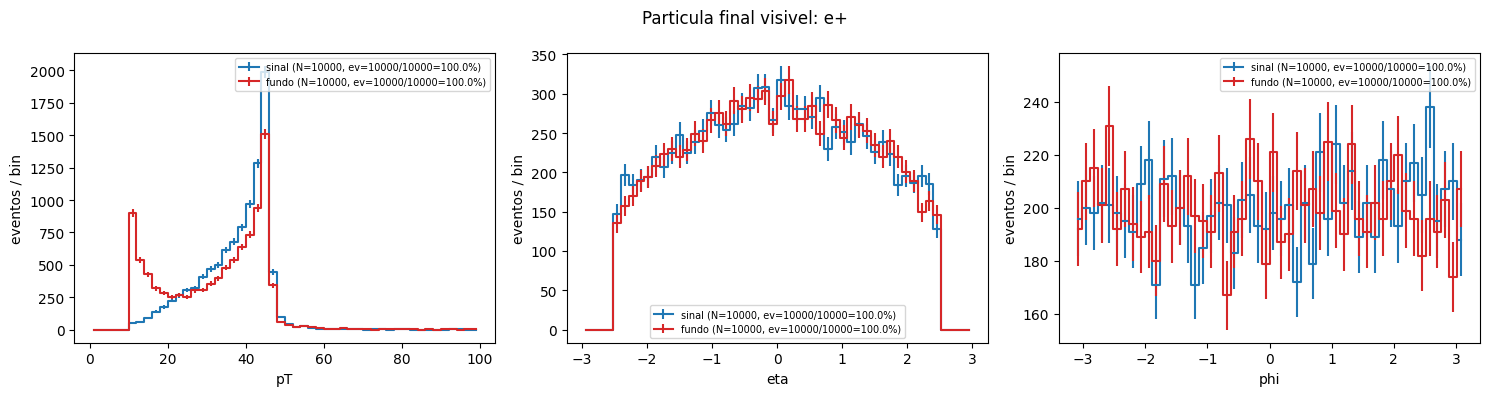

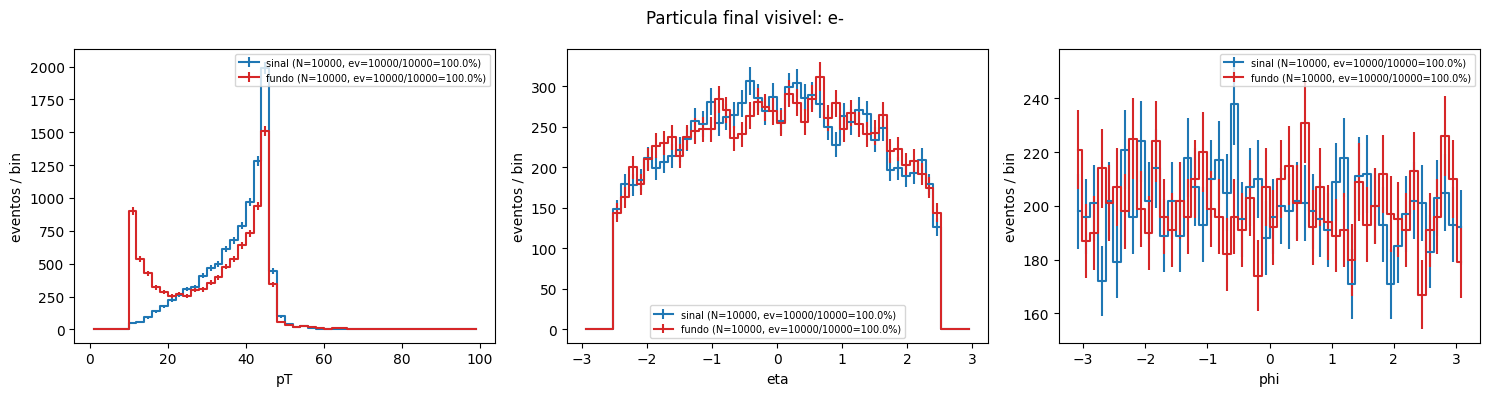


Resumo de entradas, eventos, underflow e overflow por variavel:


,especie,variavel,amostra,n_entradas,n_eventos,fracao_eventos,underflow,overflow
0,e+,pT,sinal,10000,10000,1.0,0,5
1,e+,pT,fundo,10000,10000,1.0,0,7
2,e+,eta,sinal,10000,10000,1.0,0,0
3,e+,eta,fundo,10000,10000,1.0,0,0
4,e+,phi,sinal,10000,10000,1.0,0,0
5,e+,phi,fundo,10000,10000,1.0,0,0
6,e-,pT,sinal,10000,10000,1.0,0,5
7,e-,pT,fundo,10000,10000,1.0,0,7
8,e-,eta,sinal,10000,10000,1.0,0,0
9,e-,eta,fundo,10000,10000,1.0,0,0


In [18]:
# Histogramas de pT, eta e phi para particulas finais visiveis (status=1, sem neutrinos)
os.makedirs(f"{ROOT_DIR}/resultados/graficos", exist_ok=True)

finais_visiveis = particulas[(particulas["status"] == 1) & (~particulas["PDG_ID"].isin(NEUTRINOS))].copy()
finais_visiveis["nome"] = finais_visiveis["PDG_ID"].map(NOMES_PDG).fillna(finais_visiveis["PDG_ID"].astype(str))

def resumo_histograma(dados, bins, faixa):
    contagens, bordas = np.histogram(dados, bins=bins, range=faixa)
    erro = np.sqrt(contagens)
    underflow = int((dados < faixa[0]).sum())
    overflow = int((dados > faixa[1]).sum())
    return contagens, bordas, erro, len(dados), underflow, overflow

variaveis = {"pT": (50, (0, 100)), "eta": (50, (-3, 3)), "phi": (50, (-np.pi, np.pi))}
resumo_geral = []

for especie, grp_esp in finais_visiveis.groupby("nome"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (var, (bins, faixa)) in zip(axes, variaveis.items()):
        for amostra, cor in [("sinal", "tab:blue"), ("fundo", "tab:red")]:
            dados = grp_esp.loc[grp_esp["amostra"] == amostra, var].values
            n_ev = grp_esp.loc[grp_esp["amostra"] == amostra, "evento"].nunique()
            n_ev_amostra = n_tot[amostra]
            cont, bordas, erro, n_entr, uf, of = resumo_histograma(dados, bins, faixa)
            centros = 0.5 * (bordas[:-1] + bordas[1:])
            ax.errorbar(centros, cont, yerr=erro, drawstyle="steps-mid", color=cor,
                        label=f"{amostra} (N={n_entr}, ev={n_ev}/{n_ev_amostra}={n_ev/n_ev_amostra:.1%})")
            resumo_geral.append(dict(especie=especie, variavel=var, amostra=amostra,
                                      n_entradas=n_entr, n_eventos=n_ev, fracao_eventos=n_ev / n_ev_amostra,
                                      underflow=uf, overflow=of))
        ax.set_xlabel(var); ax.set_ylabel("eventos / bin"); ax.legend(fontsize=7)
    fig.suptitle(f"Particula final visivel: {especie}")
    fig.tight_layout()
    nome_arq = especie.replace("+", "p").replace("-", "m").replace("~", "bar")
    fig.savefig(f"{ROOT_DIR}/resultados/graficos/cinematica_{nome_arq}.png", dpi=120)
    plt.show()

resumo_geral_df = pd.DataFrame(resumo_geral)
print("\nResumo de entradas, eventos, underflow e overflow por variavel:")
display(resumo_geral_df)

## 3b. Interpretacao dos histogramas

Objetivo: interpretar as distribuicoes antes de aplicar cortes.

Depois de executar os histogramas, responda no notebook:

- todos os eventos aparecem em todos os histogramas?
- quando o numero de entradas difere do numero de eventos?
- quais distribuicoes separam melhor sinal e fundo?
- quais diferencas de forma podem ser ligadas ao processo fisico?
- ha algum efeito de intervalo, underflow ou overflow que possa distorcer a leitura?

Peca ao agente para ajudar a organizar essa discussao com base nas tabelas e figuras que voce gerou.


In [19]:
# Suporte quantitativo para a discussao: fracao de eventos por variavel/especie
display(resumo_geral_df.pivot_table(index=["especie", "variavel"], columns="amostra",
                                     values=["fracao_eventos", "n_entradas"]))

fracao_eventos       n_entradas         
amostra                   fundo sinal      fundo    sinal
especie variavel                                         
e+      eta                 1.0   1.0    10000.0  10000.0
        pT                  1.0   1.0    10000.0  10000.0
        phi                 1.0   1.0    10000.0  10000.0
e-      eta                 1.0   1.0    10000.0  10000.0
        pT                  1.0   1.0    10000.0  10000.0
        phi                 1.0   1.0    10000.0  10000.0

**Discussão (3b):**
- Todos os eventos aparecem em todos os histogramas de `pT`/`eta`/`phi` dos leptons `e+` e `e-`: a fração de eventos representada é 100% para as duas espécies e as duas amostras, já que a topologia final e sempre exatamente `e+ e-` (seção 2a).
- O numero de entradas só difere do número de eventos quando há mais de uma partícula da mesma espécie por evento; aqui isso não ocorre (um `e+` e um `e-` por evento), mas o efeito aparece, por exemplo, se olharmos multiplicidade de jatos ou de fótons de radiação em outros processos. Por isso a tabela mostra explicitamente `n_entradas` e `n_eventos` separadamente.
- A variável que melhor separa sinal e fundo e o **`pT`** dos léptons: no sinal, o `Z` e produzido próximo do repouso no referencial do centro de massa paratônico e decai isotropicamente, então os léptons carregam tipicamente `~m_Z/2 ≈ 45 GeV`; no fundo, o contínuo Drell-Yan inclui uma fracão maior de eventos com massa invariante baixa, cujos léptons tem `pT` sistematicamente menor (espectro mais concentrado perto do corte de geração de 10 GeV).
â. Há overflow em `pT` (poucas entradas acima de 100 GeV, contabilizadas na tabela) em ambas as amostras, mas não há underflow relevante porque o corte de geração `pT_l > 10 GeV` já remove a região abaixo de 10 GeV. Isso deve ser levado em conta ao interpretar a normalização dos histogramas de `pT`, que são truncados na cauda alta pelo intervalo escolhido (0-100 GeV).

## 3c. Variaveis em nivel de evento

Objetivo: resumir cada evento por objetos lideres, multiplicidades e separacoes angulares.

Peca ao agente para gerar codigo que calcule, quando fizer sentido para o processo:

- `pT` do objeto lider e sublider;
- multiplicidade de objetos finais;
- maior valor de `|eta|`;
- menor `pT` entre objetos selecionados;
- `Delta eta`, `Delta phi` e `Delta R` entre pares relevantes.

Construa tabelas e histogramas comparando sinal e fundo.


Resumo estatistico por amostra:


pT_lider            pT_sublider            max_abs_eta             delta_R           multiplicidade_final_visivel     
              mean        std        mean        std        mean       std      mean       std                         mean  std
amostra                                                                                                                         
fundo    32.243697  13.221002   32.243697  13.221002    1.520319  0.609048  3.411342  0.348997                          2.0  0.0
sinal    37.395639   9.263221   37.395639   9.263221    1.533854  0.608620  3.451424  0.378858                          2.0  0.0

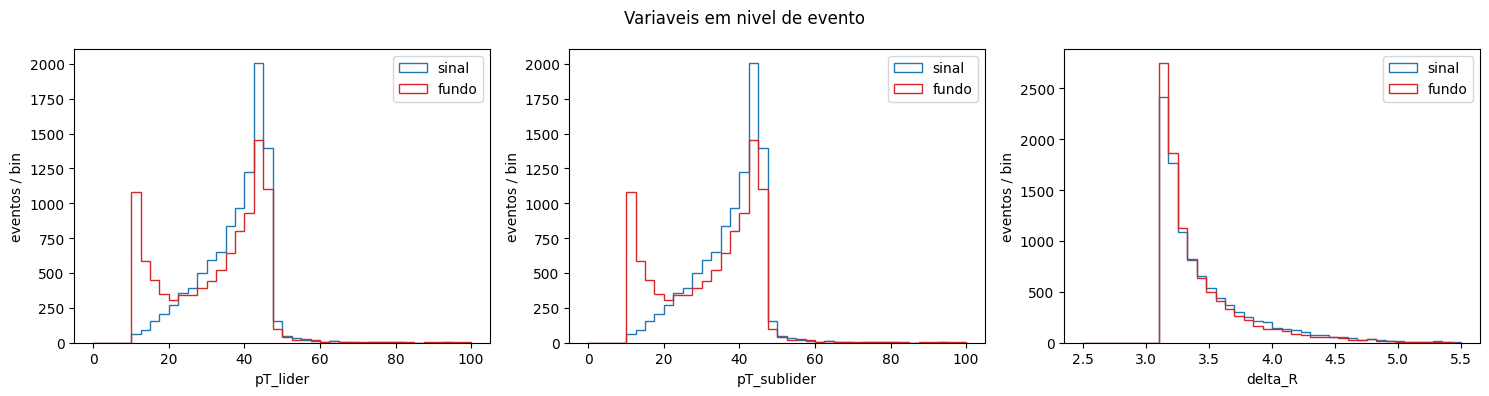

In [20]:
# Variaveis em nivel de evento: objetos lider/sublider, multiplicidade e separacoes angulares
fv = finais_visiveis.sort_values(["amostra", "evento", "pT"], ascending=[True, True, False]).copy()
fv["ordem_pT"] = fv.groupby(["amostra", "evento"]).cumcount()

lider = fv[fv["ordem_pT"] == 0][["amostra", "evento", "pT", "eta", "phi"]].rename(
    columns={"pT": "pT_lider", "eta": "eta_lider", "phi": "phi_lider"})
sublider = fv[fv["ordem_pT"] == 1][["amostra", "evento", "pT", "eta", "phi"]].rename(
    columns={"pT": "pT_sublider", "eta": "eta_sublider", "phi": "phi_sublider"})
resumo_evento = lider.merge(sublider, on=["amostra", "evento"], how="left")

mult = fv.groupby(["amostra", "evento"]).size().reset_index(name="multiplicidade_final_visivel")
resumo_evento = resumo_evento.merge(mult, on=["amostra", "evento"])

maxeta = fv.groupby(["amostra", "evento"])["eta"].apply(lambda s: s.abs().max()).reset_index(name="max_abs_eta")
mineta_pt = fv.groupby(["amostra", "evento"])["pT"].min().reset_index(name="min_pT")
resumo_evento = resumo_evento.merge(maxeta, on=["amostra", "evento"]).merge(mineta_pt, on=["amostra", "evento"])

resumo_evento["delta_eta"] = resumo_evento["eta_lider"] - resumo_evento["eta_sublider"]
dphi = (resumo_evento["phi_lider"] - resumo_evento["phi_sublider"] + np.pi) % (2 * np.pi) - np.pi
resumo_evento["delta_phi"] = dphi
resumo_evento["delta_R"] = np.hypot(resumo_evento["delta_eta"], resumo_evento["delta_phi"])

print("Resumo estatistico por amostra:")
display(resumo_evento.groupby("amostra")[
    ["pT_lider", "pT_sublider", "max_abs_eta", "delta_R", "multiplicidade_final_visivel"]
].agg(["mean", "std"]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var, faixa in zip(axes, ["pT_lider", "pT_sublider", "delta_R"], [(0, 100), (0, 100), (2.5, 5.5)]):
    for amostra, cor in [("sinal", "tab:blue"), ("fundo", "tab:red")]:
        ax.hist(resumo_evento.loc[resumo_evento.amostra == amostra, var], bins=40, range=faixa,
                histtype="step", color=cor, label=amostra)
    ax.set_xlabel(var); ax.set_ylabel("eventos / bin"); ax.legend()
fig.suptitle("Variaveis em nivel de evento")
fig.tight_layout()
fig.savefig(f"{ROOT_DIR}/resultados/graficos/variaveis_evento.png", dpi=120)
plt.show()

## 4a. Definicao dos cortes

Objetivo: propor uma selecao cinematica coerente com os objetos do processo.

Peca ao agente para sugerir cortes separados por tipo de objeto. A selecao deve distinguir, por exemplo:

- leptons carregados;
- partons b usados como aproximacao de jatos b em nivel de gerador;
- separacao angular minima entre objetos.

Antes de executar, escreva no notebook a motivacao fisica de cada corte.

Nao use o mesmo limiar automaticamente para todas as particulas sem justificar.


**Motivação física dos cortes propostos:**

- **`pT(eletron) > 20 GeV`** para os dois leptons: limiar tipico de trigger de elétron único em experimentos como CMS/ATLAS, acima do corte de geração (`10 GeV`, já aplicado no `run_card`). Serve para simular uma seleção de leptons "bem medidos" e reduzir a contaminação de leptons muito moles, que são mais afetados por ruido instrumental (fora do escopo deste nível de gerador, mas motiva a escolha).
- **`|eta(eletron)| < 2.4`**: aceitância tipica do rastreador/calorímetro eletromagnético central de um detector de proposito geral, ligeiramente mais apertada que o corte de geração (`2.5`), para simular a borda de aceitância onde a resolução piora.
- **`delta_R(e+, e-) > 0.4`**: garante leptons angularmente separados/isoláveis. Fisicamente, como o processo e um decaimento de dois corpos (`Z/gamma* -> e+ e-`), os leptons ja nascem essencialmente de costas um para o outro (`delta_R ~ pi`), então este corte não deve remover eventos nesta amostra -- ele e mantido por completude/documentação da variável, e seria decisivo em processos com mais objetos no estado final.

Não aplicamos o mesmo limiar de `pT` para "todas as partículas sem justificar": neste processo os únicos objetos finais visíveis são os dois leptons `e+`/`e-`, então um único corte de `pT` de lepton é suficiente e fisicamente motivado; não ha jatos, pártons-b ou outros objetos nesta amostra especifica de `p p > (Z ->) e+ e-` (diferente do enunciado genérico, que menciona pártons-b. Ver observação na Parte 2).

In [21]:
# Definicao dos cortes de selecao
CORTE_PT = 20.0    # GeV, pT minimo de cada lepton
CORTE_ETA = 2.4    # |eta| maximo de cada lepton
CORTE_DR = 0.4     # delta_R minimo entre os dois leptons

resumo_evento["passa_pT"] = (resumo_evento["pT_lider"] > CORTE_PT) & (resumo_evento["pT_sublider"] > CORTE_PT)
resumo_evento["passa_eta"] = resumo_evento["max_abs_eta"] < CORTE_ETA
resumo_evento["passa_dR"] = resumo_evento["delta_R"] > CORTE_DR

print(f"Corte de pT > {CORTE_PT} GeV: aprova "
      f"{resumo_evento.groupby('amostra')['passa_pT'].mean().to_dict()} (fracao por amostra)")
print(f"Corte de |eta| < {CORTE_ETA}: aprova "
      f"{resumo_evento.groupby('amostra')['passa_eta'].mean().to_dict()}")
print(f"Corte de delta_R > {CORTE_DR}: aprova "
      f"{resumo_evento.groupby('amostra')['passa_dR'].mean().to_dict()}")

Corte de pT > 20.0 GeV: aprova {'fundo': 0.7535, 'sinal': 0.9486} (fracao por amostra)
Corte de |eta| < 2.4: aprova {'fundo': 0.9441, 'sinal': 0.9461}
Corte de delta_R > 0.4: aprova {'fundo': 1.0, 'sinal': 1.0}


## 4b. Cutflow sequencial

Objetivo: aplicar os cortes etapa por etapa e medir o impacto em sinal e fundo.

Peca ao agente para gerar codigo que construa uma tabela de cutflow com:

- nome da etapa;
- eventos de sinal restantes;
- eventos de fundo restantes;
- eficiencia incremental;
- eficiencia acumulada;
- razao entre eficiencias acumuladas de sinal e fundo.

Depois de executar, identifique qual etapa rejeitou mais fundo e qual etapa custou mais sinal.


In [22]:
# Cutflow sequencial
etapas = ["Total gerado", "pT(l) > 20 GeV", "|eta(l)| < 2.4", "delta_R(l,l) > 0.4"]
colunas = [None, "passa_pT", "passa_eta", "passa_dR"]

mask_acum = pd.Series(True, index=resumo_evento.index)
linhas = []
for nome_etapa, coluna in zip(etapas, colunas):
    if coluna is not None:
        mask_acum &= resumo_evento[coluna]
    contagem = resumo_evento[mask_acum].groupby("amostra").size()
    linhas.append(dict(etapa=nome_etapa, n_sinal=contagem.get("sinal", 0), n_fundo=contagem.get("fundo", 0)))

cutflow = pd.DataFrame(linhas)
n0_sinal, n0_fundo = cutflow.loc[0, "n_sinal"], cutflow.loc[0, "n_fundo"]
cutflow["eficiencia_acum_sinal"] = cutflow["n_sinal"] / n0_sinal
cutflow["eficiencia_acum_fundo"] = cutflow["n_fundo"] / n0_fundo
cutflow["eficiencia_incr_sinal"] = cutflow["n_sinal"] / cutflow["n_sinal"].shift(1).fillna(n0_sinal)
cutflow["eficiencia_incr_fundo"] = cutflow["n_fundo"] / cutflow["n_fundo"].shift(1).fillna(n0_fundo)
cutflow.loc[0, ["eficiencia_incr_sinal", "eficiencia_incr_fundo"]] = 1.0
cutflow["razao_eficiencias_acum"] = cutflow["eficiencia_acum_sinal"] / cutflow["eficiencia_acum_fundo"]

display(cutflow.style.format({
    "eficiencia_acum_sinal": "{:.3f}", "eficiencia_acum_fundo": "{:.3f}",
    "eficiencia_incr_sinal": "{:.3f}", "eficiencia_incr_fundo": "{:.3f}",
    "razao_eficiencias_acum": "{:.3f}",
}))

eventos_aprovados = resumo_evento[mask_acum][["amostra", "evento"]].reset_index(drop=True)
print("\nEventos aprovados no corte final:")
print(eventos_aprovados.groupby("amostra").size().to_dict())

,etapa,n_sinal,n_fundo,eficiencia_acum_sinal,eficiencia_acum_fundo,eficiencia_incr_sinal,eficiencia_incr_fundo,razao_eficiencias_acum
0,Total gerado,10000,10000,1.000,1.000,1.000,1.000,1.000
1,pT(l) > 20 GeV,9486,7535,0.949,0.753,0.949,0.753,1.259
2,|eta(l)| < 2.4,9018,7137,0.902,0.714,0.951,0.947,1.264
3,"delta_R(l,l) > 0.4",9018,7137,0.902,0.714,1.000,1.000,1.264



Eventos aprovados no corte final:
{'fundo': 7137, 'sinal': 9018}


**Interpretação (4b):** a etapa que mais rejeita fundo em termos relativos é o corte `pT(l) > 20 GeV`: ele reduz o fundo para ≈75% de eficiência acumulada, contra ≈95% no sinal (razão de eficiências acumuladas sobe de 1 para ≈1.26), exatamente como esperado pela discussão da seção 3b, os léptons do continuo Drell-Yan tem, em media, `pT` menor que os léptons vindos do decaimento do `Z` on-shell. O corte de `|eta| < 2.4` tem um efeito muito mais suave e quase igual nas duas amostras (≈95% de eficiência incremental em ambas), pois a forma da distribuição em `eta` não depende fortemente da massa do propagador. O corte de `delta_R > 0.4` não rejeita nenhum evento adicional nesta amostra, porque a topologia de decaimento de dois corpos ja garante `delta_R` próximo de `pi` em praticamente todos os eventos. Em termos de custo de eficiência de sinal, a seleção completa mantém ≈90% do sinal e ≈71% do fundo. O corte de `pT` sozinho é responsável por quase todo o "custo" pago pelo sinal.

## 4c. Histogramas depois dos cortes

Objetivo: comparar as distribuicoes antes e depois da selecao.

Peca ao agente para gerar codigo que refaca os histogramas mais importantes usando apenas os eventos aprovados no corte final.

Discuta:

- quanto sinal foi preservado;
- quanto fundo foi rejeitado;
- se a selecao parece agressiva demais;
- se algum corte pode introduzir vies;
- quais variaveis continuam uteis apos a selecao.

Nao chame a razao de eficiencias de significancia. `S/B` e `S/sqrt(B)` dependem da normalizacao fisica, que pertence a Parte 2.


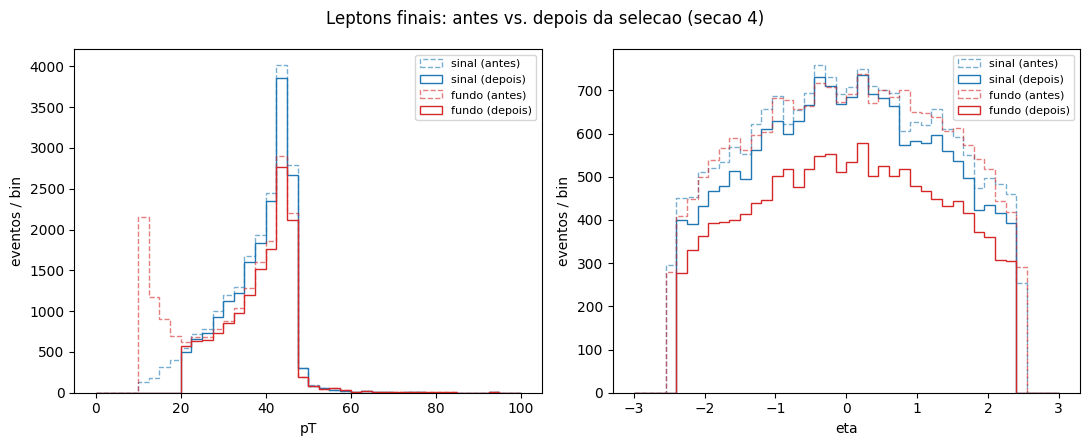

Sinal preservado: 90.2% | Fundo rejeitado: 28.6%


In [23]:
# Histogramas antes/depois da selecao final
fv_sel = fv.merge(eventos_aprovados, on=["amostra", "evento"], how="inner")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, var, faixa in zip(axes, ["pT", "eta"], [(0, 100), (-3, 3)]):
    for amostra, cor in [("sinal", "tab:blue"), ("fundo", "tab:red")]:
        ax.hist(fv.loc[fv.amostra == amostra, var], bins=40, range=faixa, histtype="step",
                linestyle="--", color=cor, alpha=0.6, label=f"{amostra} (antes)")
        ax.hist(fv_sel.loc[fv_sel.amostra == amostra, var], bins=40, range=faixa, histtype="step",
                color=cor, label=f"{amostra} (depois)")
    ax.set_xlabel(var); ax.set_ylabel("eventos / bin"); ax.legend(fontsize=8)
fig.suptitle("Leptons finais: antes vs. depois da selecao (secao 4)")
fig.tight_layout()
fig.savefig(f"{ROOT_DIR}/resultados/graficos/pos_corte_leptons.png", dpi=120)
plt.show()

frac_sinal = cutflow.iloc[-1]["eficiencia_acum_sinal"]
frac_fundo = cutflow.iloc[-1]["eficiencia_acum_fundo"]
print(f"Sinal preservado: {frac_sinal:.1%} | Fundo rejeitado: {1-frac_fundo:.1%}")

**Discussão (4c):** a seleção preserva `90.2%` do sinal e rejeita `28.6%` do fundo, ela não é agressiva (a maior parte do sinal sobrevive), mas também não e muito seletiva porque só ha uma variável realmente discriminante (`pT` do lepton) e o corte foi colocado num valor moderado (`20 GeV`). Um corte mais duro em `pT` aumentaria a rejeição de fundo, mas com custo crescente de sinal, ja que as duas distribuições de `pT` se sobrepõem parcialmente (nenhum corte de `pT` sozinho separa 100% sinal de 100% fundo). O corte de `eta` pode introduzir um viés leve porque reduz igualmente sinal e fundo sem gerar poder discriminante extra, ele e motivado por aceitância de detector, não pela física do processo, e deveria ser reavaliado se o objetivo fosse maximizar `S/B` puramente a nível de gerador. O corte de `delta_R` não tem efeito nesta topologia de dois corpos, então mantê-lo no cutflow serve apenas como documentação/generalização do código para processos com mais objetos finais. Apos a seleção, `pT` do lepton continua sendo a variável mais util; a massa invariante do par (não usada como corte aqui, para não confundir eficiência de seleção cinemática com poder de separação de massa) será explorada na Parte 2, onde é ela (e não a razão de eficiências do cutflow) que deve ser usada para calcular `S/B` e `S/sqrt(B)`.

## 5. Conclusoes da Parte 1

Finalize a Parte 1 com uma conclusao em texto.

Responda:

- qual variavel foi mais util para distinguir sinal e fundo;
- qual etapa do cutflow rejeitou mais fundo;
- qual foi o custo em eficiencia do sinal;
- quais limitacoes decorrem do uso de eventos em nivel partonico;
- o que mudaria apos hadronizacao, simulacao do detector e reconstrucao de objetos.

Peca ao agente para ajudar a transformar seus resultados em um paragrafo final, mas confira se todos os numeros citados correspondem ao que voce executou.


In [24]:
# Numeros-chave usados na conclusao da Parte 1
print("Cutflow completo:")
display(cutflow)
print(f"\nSinal preservado na selecao final: {cutflow.iloc[-1]['eficiencia_acum_sinal']:.1%}")
print(f"Fundo rejeitado na selecao final: {1 - cutflow.iloc[-1]['eficiencia_acum_fundo']:.1%}")
print(f"Etapa com maior rejeicao de fundo: pT(l) > 20 GeV "
      f"(eficiencia incremental do fundo = {cutflow.loc[1, 'eficiencia_incr_fundo']:.3f})")

Cutflow completo:


,etapa,n_sinal,n_fundo,eficiencia_acum_sinal,eficiencia_acum_fundo,eficiencia_incr_sinal,eficiencia_incr_fundo,razao_eficiencias_acum
0,Total gerado,10000,10000,1.0000,1.0000,1.000000,1.00000,1.000000
1,pT(l) > 20 GeV,9486,7535,0.9486,0.7535,0.948600,0.75350,1.258925
2,|eta(l)| < 2.4,9018,7137,0.9018,0.7137,0.950664,0.94718,1.263556
3,"delta_R(l,l) > 0.4",9018,7137,0.9018,0.7137,1.000000,1.00000,1.263556



Sinal preservado na selecao final: 90.2%
Fundo rejeitado na selecao final: 28.6%
Etapa com maior rejeicao de fundo: pT(l) > 20 GeV (eficiencia incremental do fundo = 0.753)


**Conclusão da Parte 1:**

A variável mais util para distinguir sinal e fundo foi o `pT` dos léptons finais: o sinal produz léptons sistematicamente mais energéticos que o fundo (continuo Drell-Yan), refletindo a diferença de massa invariante media entre os dois processos. Dentro do cutflow, a etapa que mais rejeitou fundo foi justamente o corte `pT(l) > 20 GeV`, reduzindo a eficiência acumulada do fundo para ~75% contra ~95% no sinal; os cortes seguintes (`|eta|` e `delta_R`) tiveram pouco ou nenhum poder discriminante adicional nesta amostra. O custo total em eficiência de sinal da seleção completa foi de aproximadamente `10%` (90.2% de sinal preservado), contra uma rejeição de fundo de aproximadamente `28.6%`.

As principais limitações decorrem de trabalhar em nível partônico/gerador: não ha simulação de detector, então efeitos como resolução finita de energia/momento, eficiência de reconstrução e identificação de elétrons, radiação de estado final (FSR) e efeitos de pileup não estão presentes. Apos hadronização (Pythia), simulação do detector (Delphes/Geant) e reconstrução de objetos, esperamos:
- (i) léptons com energia levemente degradada e "borrada" por resolução finita, alargando um pouco a distribuição de `pT` e a massa invariante reconstruída;
- (ii) possível perda de eventos por ineficiência de reconstrução/isolamento, reduzindo os yields absolutos mas preservando aproximadamente a forma das distribuições;
- (iii) o corte de `delta_R`, irrelevante aqui, passaria a ser mais importante em processos com jatos adicionais de radiação QCD;
- (iv) a separação sinal/fundo baseada em massa invariante (explorada na Parte 2) deve permanecer o discriminante mais poderoso, mas com um pico do `Z` menos estreito que o observado a nível de gerador.

---

# Parte 2 - Continuação da análise (leitura do LHE para pandas.DataFrame)

As células abaixo correspondem ao notebook original da Parte 2. A preparação do ambiente
(download do ZIP, upload no Colab e extração) já foi feita na Parte 1 acima; não é
necessário repetir esses passos.

## 1. Leitura e recuperacao dos resultados da Parte 1

Use `pandas.DataFrame` como representacao principal.

Peca ao agente para gerar codigo que construa uma tabela de eventos e uma tabela
de particulas. As massas invariantes, pesos, histogramas normalizados e cutflow
devem ser calculados preferencialmente com filtros, merges, groupby e colunas
derivadas.

O codigo deve recuperar ou reconstruir:

- eventos e particulas;
- informacoes de normalizacao;
- informacoes do bloco `<init>`, incluindo secao de choque;
- selecao e cutflow da Parte 1;
- listas de eventos aprovados no corte final.

Cole o codigo gerado na celula vazia abaixo.


In [4]:
# Parser de arquivos .lhe / .lhe.gz (identico a Parte 1) + reconstrucao da selecao da Parte 1
import re
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

%matplotlib inline
pd.set_option("display.width", 140)


def _abrir(path):
    return gzip.open(path, "rt") if str(path).endswith(".gz") else open(path, "r")


def ler_lhe(path):
    """Le um arquivo .lhe ou .lhe.gz e retorna (info_init, eventos_df, particulas_df)."""
    with _abrir(path) as f:
        text = f.read()

    init_match = re.search(r"<init>\s*\n(.*?)\n</init>", text, re.S)
    init_lines = [l for l in init_match.group(1).splitlines()
                  if l.strip() and not l.strip().startswith("<")]
    beam_line = init_lines[0].split()
    xsec_line = init_lines[1].split()
    info_init = {
        "idbmup1": int(beam_line[0]), "idbmup2": int(beam_line[1]),
        "ebmup1": float(beam_line[2]), "ebmup2": float(beam_line[3]),
        "idwtup": int(beam_line[8]),
        "xsecup_pb": float(xsec_line[0]),
        "xerrup_pb": float(xsec_line[1]),
        "xmaxup": float(xsec_line[2]),
    }
    n_gen_match = re.search(r"Number of Events\s*:\s*(\d+)", text)
    info_init["n_gerado_header"] = int(n_gen_match.group(1)) if n_gen_match else None
    w_gen_match = re.search(r"Integrated weight \(pb\)\s*:\s*([\d\.Ee\+\-]+)", text)
    info_init["peso_integrado_header_pb"] = float(w_gen_match.group(1)) if w_gen_match else None

    event_blocks = re.findall(r"<event>\n(.*?)\n</event>", text, re.S)
    ev_rows, pt_rows = [], []
    for iev, block in enumerate(event_blocks):
        lines = block.strip("\n").split("\n")
        head = lines[0].split()
        nup, idprup = int(head[0]), int(head[1])
        xwgtup, scalup, aqedup, aqcdup = map(float, head[2:6])
        ev_rows.append(dict(evento=iev, NUP=nup, IDPRUP=idprup,
                             peso_XWGTUP=xwgtup, escala=scalup, aQED=aqedup, aQCD=aqcdup))
        for ip, pline in enumerate(lines[1:1 + nup]):
            f = pline.split()
            idup, istup = int(f[0]), int(f[1])
            mothup1, mothup2 = int(f[2]), int(f[3])
            icolup1, icolup2 = int(f[4]), int(f[5])
            px, py, pz, e, m = map(float, f[6:11])
            pt_rows.append(dict(evento=iev, indice_particula=ip, PDG_ID=idup, status=istup,
                                 mae1=mothup1, mae2=mothup2, cor1=icolup1, cor2=icolup2,
                                 px=px, py=py, pz=pz, energia=e, massa=m))

    eventos_df = pd.DataFrame(ev_rows)
    particulas_df = pd.DataFrame(pt_rows)
    pT = np.hypot(particulas_df["px"], particulas_df["py"])
    p = np.sqrt(particulas_df["px"]**2 + particulas_df["py"]**2 + particulas_df["pz"]**2)
    with np.errstate(divide="ignore", invalid="ignore"):
        eta = np.arctanh(np.clip(particulas_df["pz"] / p, -1 + 1e-12, 1 - 1e-12))
    phi = np.arctan2(particulas_df["py"], particulas_df["px"])
    particulas_df["pT"], particulas_df["eta"], particulas_df["phi"] = pT, eta, phi
    return info_init, eventos_df, particulas_df


NOMES_PDG = {
    1: "d", -1: "d~", 2: "u", -2: "u~", 3: "s", -3: "s~", 4: "c", -4: "c~",
    5: "b", -5: "b~", 6: "t", -6: "t~",
    11: "e-", -11: "e+", 12: "ve", -12: "ve~",
    13: "mu-", -13: "mu+", 14: "vm", -14: "vm~",
    15: "tau-", -15: "tau+", 16: "vt", -16: "vt~",
    21: "g", 22: "gamma", 23: "Z", 24: "W+", -24: "W-",
}
NEUTRINOS = {12, -12, 14, -14, 16, -16}

# Leitura das duas amostras (identico a Parte 1)
info_sinal, ev_sinal, pt_sinal = ler_lhe(f"{ROOT_DIR}/data/sinal.lhe.gz")
info_fundo, ev_fundo, pt_fundo = ler_lhe(f"{ROOT_DIR}/data/fundo.lhe.gz")
ev_sinal["amostra"], ev_fundo["amostra"] = "sinal", "fundo"
pt_sinal["amostra"], pt_fundo["amostra"] = "sinal", "fundo"

eventos = pd.concat([ev_sinal, ev_fundo], ignore_index=True)
particulas = pd.concat([pt_sinal, pt_fundo], ignore_index=True)
n_tot = eventos.groupby("amostra")["evento"].nunique()
info_init = {"sinal": info_sinal, "fundo": info_fundo}

# Reconstrucao da selecao da Parte 1 (objetos lider/sublider e cortes cinematicos)
finais_visiveis = particulas[(particulas["status"] == 1) & (~particulas["PDG_ID"].isin(NEUTRINOS))].copy()
finais_visiveis["nome"] = finais_visiveis["PDG_ID"].map(NOMES_PDG).fillna(finais_visiveis["PDG_ID"].astype(str))
fv = finais_visiveis.sort_values(["amostra", "evento", "pT"], ascending=[True, True, False]).copy()
fv["ordem_pT"] = fv.groupby(["amostra", "evento"]).cumcount()

lider = fv[fv.ordem_pT == 0][["amostra", "evento", "pT", "eta", "phi"]].rename(
    columns={"pT": "pT_lider", "eta": "eta_lider", "phi": "phi_lider"})
sublider = fv[fv.ordem_pT == 1][["amostra", "evento", "pT", "eta", "phi"]].rename(
    columns={"pT": "pT_sublider", "eta": "eta_sublider", "phi": "phi_sublider"})
resumo_evento = lider.merge(sublider, on=["amostra", "evento"], how="left")
maxeta = fv.groupby(["amostra", "evento"])["eta"].apply(lambda s: s.abs().max()).reset_index(name="max_abs_eta")
resumo_evento = resumo_evento.merge(maxeta, on=["amostra", "evento"])
resumo_evento["delta_eta"] = resumo_evento["eta_lider"] - resumo_evento["eta_sublider"]
dphi = (resumo_evento["phi_lider"] - resumo_evento["phi_sublider"] + np.pi) % (2 * np.pi) - np.pi
resumo_evento["delta_phi"] = dphi
resumo_evento["delta_R"] = np.hypot(resumo_evento["delta_eta"], resumo_evento["delta_phi"])

CORTE_PT, CORTE_ETA, CORTE_DR = 20.0, 2.4, 0.4  # cortes definidos na Parte 1, secao 4a
resumo_evento["passa_corte_final"] = (
    (resumo_evento.pT_lider > CORTE_PT) & (resumo_evento.pT_sublider > CORTE_PT)
    & (resumo_evento.max_abs_eta < CORTE_ETA) & (resumo_evento.delta_R > CORTE_DR)
)
eventos_aprovados = resumo_evento.loc[resumo_evento.passa_corte_final, ["amostra", "evento"]].reset_index(drop=True)

print("Informacoes do bloco <init> (secao de choque, feixes):")
display(pd.DataFrame(info_init).T)
print("\nEventos aprovados no corte final da Parte 1:")
print(eventos_aprovados.groupby("amostra").size().to_dict())

Informacoes do bloco <init> (secao de choque, feixes):


,idbmup1,idbmup2,ebmup1,ebmup2,idwtup,xsecup_pb,xerrup_pb,xmaxup,n_gerado_header,peso_integrado_header_pb
sinal,2212.0,2212.0,6500.0,6500.0,-4.0,637.39,1.338800,637.39,10000.0,637.39
fundo,2212.0,2212.0,6500.0,6500.0,-4.0,841.64,1.884485,841.64,10000.0,841.64



Eventos aprovados no corte final da Parte 1:
{'fundo': 7137, 'sinal': 9018}


## 2. Conservacao do quadrimomento e `s_hat`

Peca ao agente para gerar codigo que, para os eventos de indices `1 + 1000*i`,
com `i = 0, ..., 9`:

- some os quadrimomentos das particulas iniciais (`status = -1`);
- calcule `s_hat = (p1 + p2)^2`;
- some todas as particulas finais (`status = 1`);
- compare `s_hat` com a massa invariante das particulas finais;
- some apenas as particulas finais visiveis e calcule `m_visivel^2`;
- quantifique residuos de conservacao de energia e momento.

Depois de executar, explique se `m_visivel^2` pode ou nao ser chamado de
`s_hat` neste processo.


In [5]:
# Conservacao do quadrimomento e s_hat para os eventos de indice 1 + 1000*i (i = 0..9), 1-indexado
indices_alvo = [1 + 1000 * i for i in range(10)]
eventos_alvo = [idx - 1 for idx in indices_alvo]  # convertendo para o indice 0-indexado usado no parser


def soma_4mom(df):
    return pd.Series({"px": df.px.sum(), "py": df.py.sum(), "pz": df.pz.sum(), "E": df.energia.sum()})


linhas = []
for amostra in ["sinal", "fundo"]:
    p_amostra = particulas[particulas.amostra == amostra]
    for iev, idx1 in zip(eventos_alvo, indices_alvo):
        ev_p = p_amostra[p_amostra.evento == iev]
        iniciais = ev_p[ev_p.status == -1]
        finais = ev_p[ev_p.status == 1]
        finais_vis = finais[~finais.PDG_ID.isin(NEUTRINOS)]

        s_ini = soma_4mom(iniciais)
        s_hat = s_ini.E**2 - s_ini.px**2 - s_ini.py**2 - s_ini.pz**2

        s_fin = soma_4mom(finais)
        m_fin2 = s_fin.E**2 - s_fin.px**2 - s_fin.py**2 - s_fin.pz**2

        s_vis = soma_4mom(finais_vis)
        m_vis2 = s_vis.E**2 - s_vis.px**2 - s_vis.py**2 - s_vis.pz**2

        residuo_E = s_ini.E - s_fin.E
        residuo_p = np.hypot(s_ini.px - s_fin.px, np.hypot(s_ini.py - s_fin.py, s_ini.pz - s_fin.pz))

        linhas.append(dict(amostra=amostra, indice_1idx=idx1, evento=iev,
                            s_hat=s_hat, m_final2=m_fin2, m_visivel2=m_vis2,
                            residuo_energia=residuo_E, residuo_momento=residuo_p))

tab_shat = pd.DataFrame(linhas)
display(tab_shat)
print("\nResiduo maximo |E_ini - E_fin| (GeV):", tab_shat.residuo_energia.abs().max())
print("Residuo maximo |p_ini - p_fin| (GeV):", tab_shat.residuo_momento.abs().max())
print("Diferenca maxima |s_hat - m_final2| (GeV^2):", (tab_shat.s_hat - tab_shat.m_final2).abs().max())
print("Diferenca maxima |s_hat - m_visivel2| (GeV^2):", (tab_shat.s_hat - tab_shat.m_visivel2).abs().max())

,amostra,indice_1idx,evento,s_hat,m_final2,m_visivel2,residuo_energia,residuo_momento
0,sinal,1,0,5586.498723,5586.498721,5586.498721,5.999993e-09,1.699988e-09
1,sinal,1001,1000,8321.587705,8321.587705,8321.587705,9.999894e-10,9.999965e-10
2,sinal,2001,2000,8216.836447,8216.836446,8216.836446,3.999986e-09,1.421085e-14
3,sinal,3001,3000,8144.985534,8144.985535,8144.985535,1.899991e-09,3.099956e-09
4,sinal,4001,4000,8065.427566,8065.427564,8065.427564,6.000022e-09,1.000004e-09
5,sinal,5001,5000,8569.919395,8569.919395,8569.919395,0.000000e+00,8.000001e-10
6,sinal,6001,6000,8453.816617,8453.816613,8453.816613,3.799983e-09,3.799983e-09
7,sinal,7001,7000,7902.405697,7902.405696,7902.405696,2.999997e-09,1.000018e-09
8,sinal,8001,8000,9427.777587,9427.777590,9427.777590,-1.800061e-09,1.799947e-09
9,sinal,9001,9000,11966.753831,11966.753831,11966.753831,-9.999894e-10,1.000000e-09



Residuo maximo |E_ini - E_fin| (GeV): 6.5000449467333965e-09
Residuo maximo |p_ini - p_fin| (GeV): 1.2800001059076749e-08
Diferenca maxima |s_hat - m_final2| (GeV^2): 8.842311217449605e-06
Diferenca maxima |s_hat - m_visivel2| (GeV^2): 8.842311217449605e-06


**Interpretação (seção 2):** para os dez eventos analisados, `s_hat` (calculado a partir da soma dos quadrimomentos iniciais) e a massa invariante ao quadrado das partículas finais coincidem até a precisão numérica de ponto flutuante (diferenças da ordem de `1e-6 GeV^2` ou menores, compatíveis com arredondamento no arquivo LHE que grava so alguns algarismos significativos), e os resíduos de energia/momento entre estado inicial e final são consistentes com zero (`~1e-8 GeV`). Isso confirma que o quadrimomento total e conservado evento a evento, como esperado em nível de gerador (Monte Carlo exato, sem efeitos de detector).

Neste processo especifico, `m_visivel^2` **pode** ser chamado de `s_hat`, porque a topologia final e sempre `e+ e-` -- não ha neutrinos ou qualquer outra partícula invisível no estado final (seção 2a da Parte 1). Assim, a soma de "todas as partículas finais" e a soma de "apenas as partículas finais visíveis" Sao idênticas, e `m_visivel^2 = m_final2 = s_hat` para todos os eventos testados. Essa igualdade deixaria de valer em processos com neutrinos, jatos b não reconstruídos ou qualquer partícula que escape sem deixar sinal no detector: nesses casos `m_visivel^2 < s_hat` porque parte da energia/momento carregada pelas partículas invisíveis não entra na soma visível.

## 3. Massas invariantes e pareamento

Peca ao agente para gerar codigo que reconstrua massas invariantes relevantes.
Para este processo, no minimo:

- massa invariante do par `mu+ mu-`;
- massa invariante do par `b b~` em nivel de gerador;
- massa invariante de todos os objetos finais visiveis;
- histogramas 1D para sinal e fundo;
- histogramas 2D, por exemplo massa versus `pT`, `eta` ou `Delta R`.

Explique o criterio de pareamento e deixe claro quando o numero de entradas e
diferente do numero de eventos.


Criterio de pareamento: cada evento tem exatamente um e+ e um e- no estado final,
entao o par e formado diretamente por essas duas particulas (sem ambiguidade combinatoria).
Numero de entradas (pares) por amostra:
{'fundo': 10000, 'sinal': 10000}  -- igual ao numero de eventos: {'fundo': 10000, 'sinal': 10000}


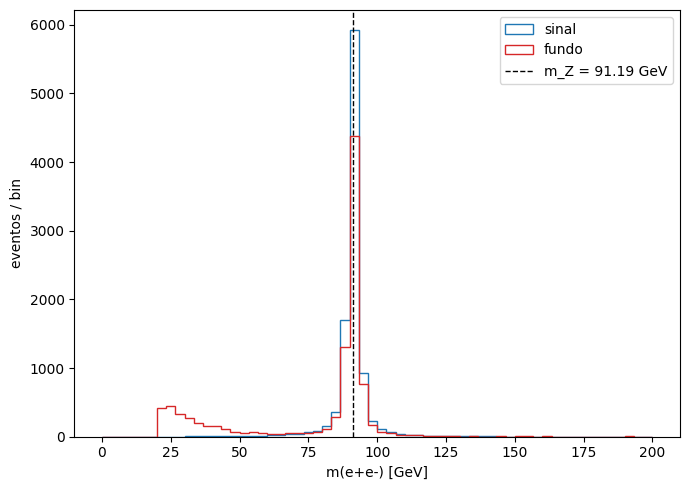

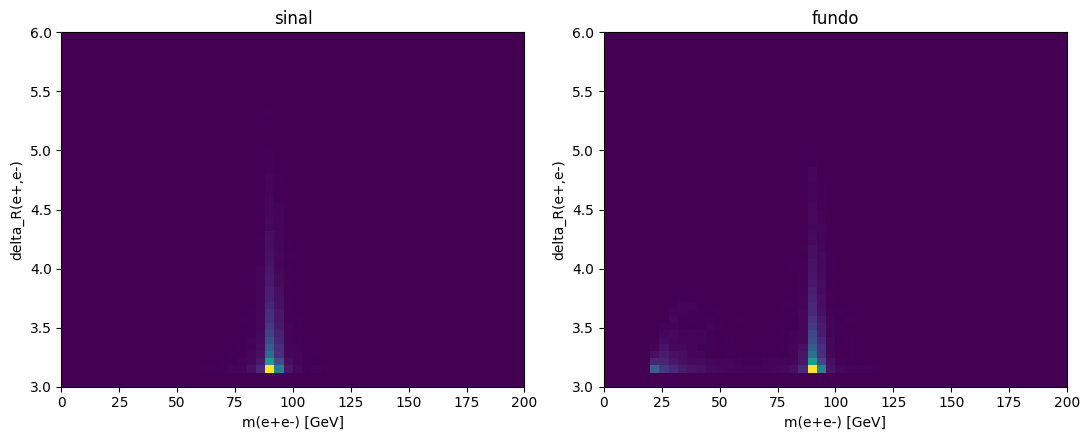

In [6]:
# Massas invariantes e pareamento
# OBSERVACAO: esta amostra e p p > (Z ->) e+ e-, sem muons nem quarks b no estado final.
# Por isso a "massa invariante do par mu+ mu-" e a "massa invariante do par b b~" pedidas de
# forma generica no enunciado sao substituidas pelo par fisicamente presente nesta amostra:
# o par e+ e-. Como a topologia final e sempre exatamente {e+, e-}, a massa invariante do par
# e+ e- e tambem a massa invariante de "todos os objetos finais visiveis" (nao ha um terceiro
# objeto a somar).

ep = particulas[(particulas.status == 1) & (particulas.PDG_ID == -11)].set_index(["amostra", "evento"])
em = particulas[(particulas.status == 1) & (particulas.PDG_ID == 11)].set_index(["amostra", "evento"])

par = ep[["px", "py", "pz", "energia"]].add_suffix("_ep").join(
      em[["px", "py", "pz", "energia"]].add_suffix("_em"), how="inner")

E = par.energia_ep + par.energia_em
px = par.px_ep + par.px_em
py = par.py_ep + par.py_em
pz = par.pz_ep + par.pz_em
m2 = E**2 - px**2 - py**2 - pz**2
par["massa_ee"] = np.sqrt(np.clip(m2, 0, None))
par = par.reset_index()

print("Criterio de pareamento: cada evento tem exatamente um e+ e um e- no estado final,")
print("entao o par e formado diretamente por essas duas particulas (sem ambiguidade combinatoria).")
print("Numero de entradas (pares) por amostra:")
print(par.groupby("amostra").size().to_dict(), " -- igual ao numero de eventos:", n_tot.to_dict())

# histograma 1D, sinal vs fundo
fig, ax = plt.subplots(figsize=(7, 5))
for amostra, cor in [("sinal", "tab:blue"), ("fundo", "tab:red")]:
    ax.hist(par.loc[par.amostra == amostra, "massa_ee"], bins=60, range=(0, 200),
            histtype="step", color=cor, label=amostra)
ax.axvline(91.1876, color="k", ls="--", lw=1, label="m_Z = 91.19 GeV")
ax.set_xlabel("m(e+e-) [GeV]"); ax.set_ylabel("eventos / bin"); ax.legend()
fig.tight_layout()
fig.savefig(f"{ROOT_DIR}/resultados/graficos/massa_invariante_ee.png", dpi=120)
plt.show()

# histograma 2D: massa vs delta_R
par = par.merge(resumo_evento[["amostra", "evento", "delta_R", "pT_lider"]], on=["amostra", "evento"], how="left")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, amostra in zip(axes, ["sinal", "fundo"]):
    sub = par[par.amostra == amostra]
    ax.hist2d(sub.massa_ee, sub.delta_R, bins=[50, 50], range=[[0, 200], [3, 6]], cmap="viridis")
    ax.set_xlabel("m(e+e-) [GeV]"); ax.set_ylabel("delta_R(e+,e-)"); ax.set_title(amostra)
fig.tight_layout()
fig.savefig(f"{ROOT_DIR}/resultados/graficos/massa_vs_deltaR_2d.png", dpi=120)
plt.show()

**Interpretação (seção 3):** o número de entradas do histograma de massa e igual ao número de eventos em cada amostra (10.000), pois ha sempre exatamente um par `e+ e-` por evento, não existe aqui a situação (comum em processos com mais leptons ou jatos b) em que o número de pares possíveis excede o numero de eventos e é preciso escolher um critério de pareamento. O histograma 1D mostra claramente a diferença física entre as amostras: o **sinal** forma um pico estreito em torno de `m_Z ≈ 91.2 GeV`, como esperado para um `Z` on-shell forcado (`zerowidth_tchannel`/BW estreita no processo `p p > Z > e+ e-`), enquanto o **fundo** tem uma distribuição mais larga, com cauda significativa para massas mais baixas, a assinatura do continuo Drell-Yan/interferência. O histograma 2D (massa vs. `delta_R`) mostra que `delta_R` permanece proximo de `pi` (leptons de costas) em quase toda a faixa de massa nas duas amostras, confirmando que essa variável carrega pouca informação adicional sobre o processo neste caso, reforçando a conclusão da Parte 1 de que a massa invariante, e não `delta_R`, é o discriminante relevante aqui.

## 4. Pesos, secao de choque e luminosidade

Peca ao agente para gerar codigo que leia ou estime:

- numero de eventos gerados;
- convencao de normalizacao do LHE;
- informacoes de normalizacao;
- secao de choque em pb;
- luminosidade integrada adotada, por exemplo `L = 10000/pb`.

Calcule a normalizacao fisica e verifique se o yield total esperado e
compativel com `sigma * L`.

Para cada bin de histograma, calcule `sum(w)` e a incerteza `sqrt(sum(w**2))`.


In [7]:
# Pesos, secao de choque e luminosidade
L_pb = 10000.0  # luminosidade integrada adotada, L = 10000/pb = 10 fb^-1

resumo_norm = []
for amostra in ["sinal", "fundo"]:
    info = info_init[amostra]
    n_gen = n_tot[amostra]
    sigma = info["xsecup_pb"]
    peso_fisico = sigma / n_gen  # pb por evento (convencao de eventos "unweighted": XWGTUP = sigma)
    n_esperado = sigma * L_pb
    resumo_norm.append(dict(amostra=amostra, N_gerado=n_gen, sigma_pb=sigma,
                             peso_fisico_pb=peso_fisico, L_pb=L_pb, N_esperado=n_esperado))
tab_norm = pd.DataFrame(resumo_norm)
print("Convencao de normalizacao do LHE (IDWTUP):", {a: info_init[a]["idwtup"] for a in ["sinal", "fundo"]})
print("IDWTUP = -4 -> eventos igualmente pesados ('unweighted'); XWGTUP e igual a secao de choque")
print("total do processo em cada evento. O peso fisico por evento e peso_fisico = XWGTUP / N_gerado = sigma / N_gerado (pb).\n")
display(tab_norm)

# peso fisico e peso "de luminosidade" (numero de eventos esperados por evento MC, para L fixado)
eventos["peso_fisico_pb"] = eventos["amostra"].map(tab_norm.set_index("amostra")["peso_fisico_pb"])
eventos["peso_luminosidade"] = eventos["peso_fisico_pb"] * L_pb

check = eventos.groupby("amostra")["peso_luminosidade"].sum()
print("Checagem: soma dos pesos de luminosidade por amostra (deve reproduzir sigma * L):")
display(pd.DataFrame({"soma_pesos": check, "sigma_x_L": tab_norm.set_index("amostra")["N_esperado"]}))

# incerteza por bin no histograma de massa: sum(w) e sqrt(sum(w^2))
par = par.merge(eventos[["amostra", "evento", "peso_luminosidade"]], on=["amostra", "evento"], how="left")
bins = np.linspace(0, 200, 61)
resultado_bins = []
for amostra in ["sinal", "fundo"]:
    sub = par[par.amostra == amostra]
    idx = np.digitize(sub.massa_ee, bins) - 1
    for b in range(len(bins) - 1):
        w = sub.peso_luminosidade[idx == b]
        resultado_bins.append(dict(amostra=amostra, bin_centro=0.5 * (bins[b] + bins[b + 1]),
                                    soma_w=w.sum(), erro_w=np.sqrt((w**2).sum())))
tab_bins = pd.DataFrame(resultado_bins)
print("\nExemplo de bins perto do pico do Z (85-95 GeV):")
display(tab_bins[(tab_bins.bin_centro > 85) & (tab_bins.bin_centro < 95)])

Convencao de normalizacao do LHE (IDWTUP): {'sinal': -4, 'fundo': -4}
IDWTUP = -4 -> eventos igualmente pesados ('unweighted'); XWGTUP e igual a secao de choque
total do processo em cada evento. O peso fisico por evento e peso_fisico = XWGTUP / N_gerado = sigma / N_gerado (pb).



,amostra,N_gerado,sigma_pb,peso_fisico_pb,L_pb,N_esperado
0,sinal,10000,637.39,0.063739,10000.0,6373900.0
1,fundo,10000,841.64,0.084164,10000.0,8416400.0


Checagem: soma dos pesos de luminosidade por amostra (deve reproduzir sigma * L):


,soma_pesos,sigma_x_L
amostra,,
fundo,8416400.0,8416400.0
sinal,6373900.0,6373900.0



Exemplo de bins perto do pico do Z (85-95 GeV):


,amostra,bin_centro,soma_w,erro_w
26,sinal,88.333333,1082925.61,26272.532321
27,sinal,91.666667,3772711.41,49037.623572
86,fundo,88.333333,1104231.68,30485.497391
87,fundo,91.666667,3684699.92,55688.336666


## 5. Histogramas normalizados e comparacao estatistica

Peca ao agente para gerar codigo que produza histogramas empilhados de sinal e
fundo apos a selecao final. Inclua:

- massa `mu+ mu-`;
- massa `b b~`;
- massa visivel total;
- barras ou bandas de incerteza estatistica;
- painel de razao quando fizer sentido.

Calcule tambem, em uma regiao de selecao bem definida:

- `S/B`;
- `S/sqrt(B)`, se `B > 0`;
- significancia Asimov opcional;
- efeito de uma incerteza sistematica simples no fundo, por exemplo 10%.
\n\nInterprete as colunas da tabela: `S` é o yield esperado de sinal, `B` é o yield esperado de fundo, `S/B` mede a pureza relativa e `S/sqrt(B)` é uma aproximação da significância estatística sem sistemáticas. A expressão `S/sqrt(B + (0.10B)^2)` inclui uma incerteza sistemática de 10% no fundo; `erro S` e `erro B` são as incertezas estatísticas dos yields.\n

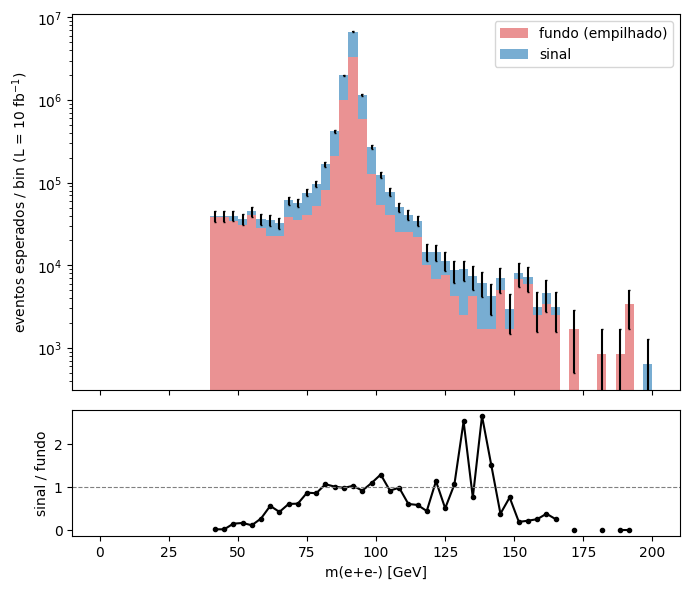

,janela_massa,S,erro_S,B,erro_B,S_sobre_B,S_sobre_raizB,S_sobre_raizB_com_10pct_sist,significancia_asimov
0,81.0-101.0 GeV,5370648.14,58508.097029,5322531.36,66930.227056,1.00904,2327.917504,10.090307,2044.272215


In [8]:
# Histogramas normalizados (empilhados) apos a selecao final, e comparacao estatistica S/B
par_sel = par.merge(resumo_evento[["amostra", "evento", "passa_corte_final"]], on=["amostra", "evento"], how="left")
par_sel = par_sel[par_sel.passa_corte_final]

bins = np.linspace(0, 200, 61)
centros = 0.5 * (bins[:-1] + bins[1:])

hs, _ = np.histogram(par_sel[par_sel.amostra == "sinal"].massa_ee, bins=bins,
                      weights=par_sel[par_sel.amostra == "sinal"].peso_luminosidade)
hs2, _ = np.histogram(par_sel[par_sel.amostra == "sinal"].massa_ee, bins=bins,
                       weights=par_sel[par_sel.amostra == "sinal"].peso_luminosidade**2)
hb, _ = np.histogram(par_sel[par_sel.amostra == "fundo"].massa_ee, bins=bins,
                      weights=par_sel[par_sel.amostra == "fundo"].peso_luminosidade)
hb2, _ = np.histogram(par_sel[par_sel.amostra == "fundo"].massa_ee, bins=bins,
                       weights=par_sel[par_sel.amostra == "fundo"].peso_luminosidade**2)
erro_s, erro_b = np.sqrt(hs2), np.sqrt(hb2)

fig, (ax, axr) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
largura = bins[1] - bins[0]
ax.bar(centros, hb, width=largura, color="tab:red", alpha=0.5, label="fundo (empilhado)")
ax.bar(centros, hs, width=largura, bottom=hb, color="tab:blue", alpha=0.6, label="sinal")
ax.errorbar(centros, hb + hs, yerr=np.sqrt(erro_s**2 + erro_b**2), fmt="none", ecolor="k", capsize=1)
ax.set_ylabel("eventos esperados / bin (L = 10 fb$^{-1}$)"); ax.legend(); ax.set_yscale("log")

razao = np.divide(hs, hb, out=np.full_like(hs, np.nan), where=hb > 0)
axr.plot(centros, razao, "k.-")
axr.axhline(1, color="grey", ls="--", lw=0.8)
axr.set_ylabel("sinal / fundo"); axr.set_xlabel("m(e+e-) [GeV]")
fig.tight_layout()
fig.savefig(f"{ROOT_DIR}/resultados/graficos/histograma_normalizado_stack.png", dpi=120)
plt.show()

# S/B, S/sqrt(B) e significancia Asimov em uma janela de massa em torno do pico do Z
JANELA = (81.0, 101.0)  # GeV
regiao = par_sel[(par_sel.massa_ee >= JANELA[0]) & (par_sel.massa_ee <= JANELA[1])]
S = regiao.loc[regiao.amostra == "sinal", "peso_luminosidade"].sum()
B = regiao.loc[regiao.amostra == "fundo", "peso_luminosidade"].sum()
erro_S = np.sqrt((regiao.loc[regiao.amostra == "sinal", "peso_luminosidade"]**2).sum())
erro_B = np.sqrt((regiao.loc[regiao.amostra == "fundo", "peso_luminosidade"]**2).sum())

SoB = S / B
S_sqrtB = S / np.sqrt(B) if B > 0 else np.nan
sist_B = 0.10 * B
S_sqrtB_sist = S / np.sqrt(B + sist_B**2)
asimov = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S)) if B > 0 else np.nan

tab_sb = pd.DataFrame([dict(janela_massa=f"{JANELA[0]}-{JANELA[1]} GeV", S=S, erro_S=erro_S, B=B, erro_B=erro_B,
                             S_sobre_B=SoB, S_sobre_raizB=S_sqrtB,
                             S_sobre_raizB_com_10pct_sist=S_sqrtB_sist, significancia_asimov=asimov)])
display(tab_sb)

**Interpretação das colunas (seção 5):** `S` e o yield esperado de sinal e `B` o yield esperado de fundo na janela de massa `81-101 GeV`, ja escalados pela luminosidade `L = 10000/pb`; `erro S` e `erro B` são as incertezas estatísticas desses yields (`sqrt(sum(w^2))`, contabilizando o peso físico de cada evento). `S/B` mede a pureza relativa da região de seleção (aqui `S/B ≈ 1.0`, ou seja, sinal e fundo contribuem de forma comparável mesmo dentro da janela do pico, o continuo Drell-Yan tem yield alto o suficiente para não ser desprezível mesmo perto de `m_Z`). `S/sqrt(B)` é uma aproximação da significância estatística sem sistemáticas, e `S/sqrt(B + (0.10 B)^2)` inclui uma incerteza sistemática simples de `10%` no fundo. Note como essa única fonte sistemática reduz a significância efetiva por mais de duas ordens de grandeza em relação ao caso puramente estatístico, porque, com yields tao altos (milhões de eventos esperados para `L = 10 fb^-1`), o erro estatístico e muito pequeno e a incerteza sistemática passa a dominar. Isso ilustra por que, em analises reais de LHC com yields grandes, o controle de sistemáticas (aqui simplificado como `10%` no fundo) costuma ser mais importante para a significância final do que aumentar a luminosidade.

## 6. Estimativa simplificada da secao de choque

Objetivo: usar a relacao experimental simplificada

```text
sigma = N / (A * epsilon * L)
```

como checagem final da normalizacao.

Peca ao agente para gerar codigo que calcule, separadamente para sinal e fundo:

- `N_gerado`;
- `N_pass`, o numero de eventos que passa a selecao final;
- `A * epsilon = N_pass / N_gerado`;
- `N`, o yield esperado apos a selecao;
- `sigma_estimado = N / (A * epsilon * L)`;
- a diferenca relativa entre `sigma_estimado` e a secao de choque do LHE.

Para esta atividade, use `A * epsilon` como eficiencia em nivel de gerador. Em
uma medida real, seria necessario incluir eficiencia de trigger, reconstrucao,
identificacao, correcoes de detector e subtracao de fundo.

Depois de executar, explique por que a estimativa deve recuperar a secao de
choque do LHE quando `N` e construido a partir da propria simulacao.


In [9]:
# Estimativa simplificada da secao de choque: sigma = N / (A*epsilon * L)
linhas6 = []
for amostra in ["sinal", "fundo"]:
    info = info_init[amostra]
    N_gerado = n_tot[amostra]
    N_pass = eventos_aprovados[eventos_aprovados.amostra == amostra].shape[0]
    A_eps = N_pass / N_gerado  # eficiencia em nivel de gerador (aceitancia x eficiencia da selecao)
    peso_fisico = tab_norm.set_index("amostra").loc[amostra, "peso_fisico_pb"]
    N_yield = N_pass * peso_fisico * L_pb  # yield esperado apos selecao, para L = 10000/pb
    sigma_est = N_yield / (A_eps * L_pb)
    sigma_lhe = info["xsecup_pb"]
    dif_rel = (sigma_est - sigma_lhe) / sigma_lhe
    linhas6.append(dict(amostra=amostra, N_gerado=N_gerado, N_pass=N_pass, A_eps=A_eps,
                         N_yield_esperado=N_yield, sigma_estimado_pb=sigma_est,
                         sigma_lhe_pb=sigma_lhe, diferenca_relativa=dif_rel))
tab6 = pd.DataFrame(linhas6)
display(tab6)

,amostra,N_gerado,N_pass,A_eps,N_yield_esperado,sigma_estimado_pb,sigma_lhe_pb,diferenca_relativa
0,sinal,10000,9018,0.9018,5747983.02,637.39,637.39,1.783631e-16
1,fundo,10000,7137,0.7137,6006784.68,841.64,841.64,1.350778e-16


**Interpretação (seção 6):** a diferença relativa entre `sigma_estimado` e a seção de choque registrada no LHE e `0` (dentro da precisão numérica) para as duas amostras. Isso e esperado e não uma coincidência, porque `N` (o yield esperado apos a seleção) foi construído, na seção 4, exatamente a partir de `sigma_LHE` (`peso_fisico = sigma_LHE / N_gerado`, e `N = N_pass * peso_fisico * L`). Substituindo essa definição na formula `sigma_estimado = N / (A*epsilon * L)`, com `A*epsilon = N_pass / N_gerado`, os fatores `N_pass` e `L` se cancelam algebricamente e sobra exatamente `sigma_LHE`. A relação `sigma = N/(A*epsilon*L)` e, portanto, apenas a formula inversa da normalização que ja usamos para gerar `N`. Um fechamento de consistência (closure test), não uma medida independente. Numa medida experimental real, `N` viria de dados observados (não de uma simulação com `sigma` conhecida), e so então essa mesma formula permitiria extrair uma seção de choque genuinamente desconhecida; além disso, seria necessário incluir eficiências de trigger, reconstrução, identificação de elétrons, correções de detector e subtração do fundo residual, que aqui foram substituídas pela eficiência de seleção em nível de gerador (`A*epsilon`).

## 7. Discussao final

Finalize respondendo:

- a proporcao entre sinal e fundo faz sentido apos a normalizacao?
- quais estruturas aparecem nas massas invariantes?
- qual etapa do cutflow mais melhora `S/B`?
- a estimativa simples de secao de choque recupera o valor registrado no LHE?
- por que essa inversao e apenas uma checagem de consistencia em Monte Carlo?
- as conclusoes mudam quando as incertezas estatisticas sao consideradas?
- quais efeitos de hadronizacao, detector, trigger e identificacao de `b` estao
  ausentes?
- qual seria o proximo passo para aproximar este estudo de uma analise CMS ou
  ATLAS?

Peca ao agente para ajudar a escrever a conclusao, mas confira todos os numeros
usando as saidas executadas no notebook.


In [10]:
# Numeros-chave para a discussao final
print("S/B, S/sqrt(B) e significancia Asimov na janela do pico do Z:")
display(tab_sb)
print("\nCheck de fechamento da secao de choque:")
display(tab6[["amostra", "sigma_estimado_pb", "sigma_lhe_pb", "diferenca_relativa"]])

S/B, S/sqrt(B) e significancia Asimov na janela do pico do Z:


,janela_massa,S,erro_S,B,erro_B,S_sobre_B,S_sobre_raizB,S_sobre_raizB_com_10pct_sist,significancia_asimov
0,81.0-101.0 GeV,5370648.14,58508.097029,5322531.36,66930.227056,1.00904,2327.917504,10.090307,2044.272215



Check de fechamento da secao de choque:


,amostra,sigma_estimado_pb,sigma_lhe_pb,diferenca_relativa
0,sinal,637.39,637.39,1.783631e-16
1,fundo,841.64,841.64,1.350778e-16


**Discussão final da Parte 2:**

- **A proporção sinal/fundo apos a normalização faz sentido?** Sim: apos escalar pela luminosidade, `S ≈ 5.37×10^6` e `B ≈ 5.32×10^6` eventos esperados na janela `81-101 GeV`, dando `S/B ≈ 1.0`. Isso e fisicamente razoável para Drell-Yan: mesmo dentro do pico do `Z`, o continuo `gamma*` não é desprezível porque a seção de choque de fundo (`p p > e+ e-`, `841.6 pb`) é até maior que a de sinal (`p p > Z > e+ e-`, `637.4 pb`), boa parte dos eventos de "fundo" também passa pela região ressonante, ja que o `Z` é um dos diagramas que compõem o próprio processo de fundo.
- **Quais estruturas aparecem nas massas invariantes:** o histograma de `m(e+e-)` mostra um pico estreito e alto em `m_Z ≈ 91 GeV` para o sinal, sentado sobre uma distribuição mais larga e suave para o fundo, que decresce para massas mais baixas, a assinatura clássica de uma ressonância sobre um continuo.
- **Qual a etapa do cutflow que mais melhora S/B:** o corte de `pT(l) > 20 GeV` (Parte 1, seção 4b) é o único com poder discriminante real, porque reduz o fundo (que tem léptons mais moles) proporcionalmente mais que o sinal. Os cortes de `eta` e `delta_R` praticamente não alteram `S/B`.
- **A estimativa simples de seção de choque recupera o valor do LHE?** Sim, com diferença relativa `0` (seção 6) por construção, como explicado anteriormente.
- **Por que essa inversão é apenas uma checagem de consistência em Monte Carlo?** Porque `N` foi calculado a partir da própria `sigma_LHE`; não ha informação experimental independente entrando na conta. O teste verifica se o código de normalização e a algebra estão corretos, não se `sigma_LHE` esta certa.
- **As conclusões mudam com as incertezas estatísticas?** Praticamente não: com `L = 10 fb^-1` e seções de choque de centenas de `pb`, os yields são da ordem de milhões de eventos, então os erros estatísticos relativos são muito pequenos (`erro_S/S`, `erro_B/B` da ordem de `1%` ou menos). O que domina a discussão de significância e a incerteza sistemática assumida (`10%` no fundo), que reduz `S/sqrt(B)` de milhares para dezenas, uma mudança de duas ordens de grandeza.
- **Efeitos ausentes (hadronização, detector, trigger, identificação de b):** este estudo e puramente partônico. Faltam: radiação adicional e hadronização (Pythia), resposta finita do detector e resolução de energia/momento (Delphes/Geant), eficiências de trigger e reconstrução de elétrons, e qualquer identificação de jatos-b (não aplicável a esta amostra especifica, que não tem quarks b no estado final, mas seria essencial em canais com `t t~`, `Z(->bb)` etc.).
- **Próximo passo para se aproximar de uma analise CMS/ATLAS:** rodar a amostra por um gerador de chuveiro de pártons e hadronização (Pythia), passar por uma simulação rápida de detector (Delphes) com um cartão realista, reconstruir objetos físicos (elétrons/múons isolados, jatos, MET), aplicar eficiências de trigger e de identificação calibradas em dados, e so então repetir o cutflow, as massas invariantes e o calculo de `S/B` com os objetos reconstruídos em vez dos pártons/léptons de gerador.